<img src="logo_UNSAM.jpg" align="right" width="120" /> 
<br><br><br><br>
<div style="text-align: center;">

### Analisis y procesamiento de señales 1C 2026
# Trabajo Práctico Nº4

### Melanie amicucci

<br>
</div>

# Introducción
En este trabajo se estudió la estimación espectral de una señal senoidal en ruido blanco gaussiano aditivo (AWGN), utilizando distintos tipos de ventanas temporales.

La señal analizada estuvo compuesta por una senoidal de amplitud conocida y frecuencia aleatoria alrededor de una frecuencia central, a la cual se le agregó ruido gaussiano. A partir de múltiples realizaciones de la señal, se calcularon estimadores de amplitud y frecuencia utilizando la FFT y luego se evaluó el comportamiento los estimadores mediante el cálculo experimental del sesgo y la varianza.

Para el análisis se utilizaron distintas ventanas espectrales: rectangular (sin ventana), Flat Top, Blackman y Hamming. Luego, se compararon los resultados obtenidos para distintos valores de SNR, observando cómo el ruido y el tipo de ventana afectan la precisión y dispersión de las estimaciones realizadas.


# GENERAR LA SEÑAL
Para la generación de la señal se definieron inicialmente los parámetros principales del experimento: una cantidad de N = 1000 muestras por realización y un total de R = 200 realizaciones independientes. La amplitud de la senoidal se fijó como:

$$
a_0 = \sqrt{2}
$$

de manera que la potencia de la señal senoidal resulte unitaria, ya que para una senoidal se cumple:

$$
P_{sen} = \frac{A^2}{2}
$$

por lo tanto:
$$
P_{sen} = \frac{(\sqrt{2})^2}{2} = 1W
$$ 
Además, se utilizó:
$$
np.random.seed(0)
$$

con el objetivo de fijar la semilla del generador aleatorio. Esto permite que al ejecutar nuevamente el código se obtengan exactamente los mismos valores aleatorios y, por lo tanto, los mismos resultados experimentales.

La frecuencia angular central de la señal se definió como:
$$
\Omega_0 = \frac{\pi}{2}
$$

mientras que la frecuencia angular de cada realización se obtuvo mediante:

$$
\Omega_1 = \Omega_0 + f_r \frac{2\pi}{N}
$$

donde $$f_r$$ es una variable aleatoria uniforme entre [-2:2] 

El broadcasting permite que NumPy expanda automáticamente las dimensiones de ambos vectores sin necesidad de replicarlos manualmente. De esta forma, al multiplicar un vector columna R x 1 por un vector fila 1 x N, se obtiene directamente una matriz de dimensiones R x N, donde cada fila corresponde a una realización distinta de la señal y cada columna representa una muestra temporal.

Finalmente, se agregó ruido blanco gaussiano aditivo (AWGN) utilizando una distribución normal de media nula. La potencia del ruido se calculó a partir del SNR especificado en la consigna: 10dB y 3 dB


### Señal de 10dB

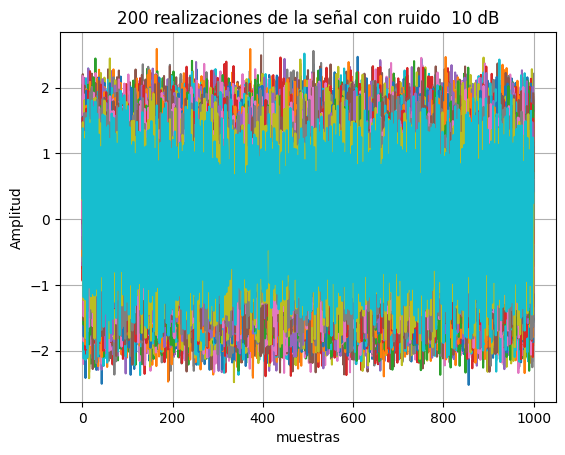

In [1]:
import numpy as np  #importar la libreria numpys
from scipy import signal
import matplotlib.pyplot as plt
np.random.seed(0)
N = 1000
R = 200

a0 = np.sqrt(2)

Omega0 = np.pi/2          # frecuencia angular central
fr = np.random.uniform(-2, 2, R)

Omega1 = Omega0 + fr * (2*np.pi/N) # Omega1 segun la consigna
Omega1 = Omega1.reshape(R, 1) # lo paso a vector columna: R x 1

n = np.arange(N)
n = n.reshape(1, N)

argumento = Omega1 * n #NumPy hace broadcasting automáticamente y te queda una matriz de: 200 X 1000
#%%ruido para SNR = 10 dB

mu = 0

SNR_db = 10
SNR = 10**(SNR_db/10)

P_sen = a0**2 / 2
P_ruido = P_sen / SNR

sigma = np.sqrt(P_ruido)

na = np.random.normal(mu, sigma, (R,N)) #RUIDO

#%% señal completa
xx = a0 * np.sin(argumento) + na

plt.figure()
plt.plot(xx.T)
plt.title("200 realizaciones de la señal con ruido  10 dB")
plt.xlabel("muestras")
plt.ylabel("Amplitud")
plt.grid()
plt.show()

Figura 1: Realizaciones de la señal senoidal con ruido gaussiano aditivo para un SNR de 10 dB.

#### Estimadores: de amplitud y de frecuencia
Para estimar experimentalmente la amplitud y la frecuencia de cada realización de la señal, se utilizaron los estimadores definidos en la consigna a partir del módulo de la Transformada Discreta de Fourier (DFT).

El estimador de amplitud utilizado fue:

$$
\hat a_1^i = |X_w^i(\Omega_0)|
$$

el cual consiste en evaluar el módulo del espectro en la frecuencia angular central $$\Omega_0$$

Por otro lado, el estimador de frecuencia se definió como:

$$
\hat \Omega_1^i = \arg \max_{\Omega} {|X_w^i(\Omega)|}
$$

es decir, la frecuencia correspondiente al máximo valor del módulo espectral de cada realización.

Para implementar ambos estimadores se calculó la FFT de las señales generadas y posteriormente se obtuvo el módulo espectral. Luego, el estimador de amplitud se evaluó en el bin correspondiente a:

$$
k_0 = \frac{N}{4}
$$

mientras que el estimador de frecuencia se obtuvo buscando el índice del máximo espectral y convirtiéndolo nuevamente a frecuencia angular. 

In [2]:
#%% estimador de amplitud 

a = np.fft.fft(xx)

amodulo = np.abs(a)
# evaluo en k0 = N/4
amod_evaluado = amodulo[:, N//4] * (2/N)

#%% estimador de frecuencia 

arg_max = np.argmax(amodulo, axis=1)
omega_estimado = 2*np.pi*arg_max/N

#### Ventanas 
Con el objetivo de analizar cómo influye el ventaneo sobre los estimadores espectrales, se aplicaron distintas ventanas temporales antes del cálculo de la FFT. El uso de ventanas permite reducir el leakage espectral producido cuando la frecuencia de la señal no coincide exactamente con un bin de la DFT.

En este trabajo se utilizaron las ventanas Flat Top y Blackman propuestas en la consigna, además de una ventana Hamming. Esta ventana fue seleccionada debido a que presenta un buen compromiso entre reducción de lóbulos laterales y simplicidad de implementación, permitiendo disminuir el leakage espectral respecto de la ventana rectangular.

Cada ventana fue multiplicada por las realizaciones de la señal antes de aplicar la FFT. Posteriormente, sobre los espectros obtenidos se calcularon nuevamente los estimadores de amplitud y frecuencia, con el fin de comparar el comportamiento estadístico de cada ventaneo mediante el análisis del sesgo y la varianza.


In [3]:
#%%FLATTOP
window_flattop = signal.windows.flattop(N)

xx_flattop = xx * window_flattop

fft_flattop = np.fft.fft(xx_flattop)

mod_flattop = np.abs(fft_flattop)

# estimador de amplitud
amod_flattop = mod_flattop[:, N//4] * (2/N)

# estimador de frecuencia
argmax_flattop = np.argmax(mod_flattop, axis=1)

omega_flattop = 2*np.pi*argmax_flattop/N


#%%BLACKMAN 
window_blackman = signal.windows.blackman(N)

xx_blackman = xx * window_blackman

fft_blackman = np.fft.fft(xx_blackman)

mod_blackman = np.abs(fft_blackman)

# estimador de amplitud 
amod_blackman = mod_blackman[:, N//4] * (2/N)

# estimador de frecuencia
argmax_blackman = np.argmax(mod_blackman, axis=1)
omega_blackman = 2*np.pi*argmax_blackman/N


#%% HAMMING
window_hamming = signal.windows.hamming(N)

xx_hamming = xx * window_hamming

fft_hamming = np.fft.fft(xx_hamming)

mod_hamming = np.abs(fft_hamming)

# estimador de amplitud
amod_hamming = mod_hamming[:, N//4] * (2/N)

# estimador de frecuencia
argmax_hamming = np.argmax(mod_hamming, axis=1)

omega_hamming = 2*np.pi*argmax_hamming/N


#### Histograma
El objetivo principal del histograma es visualizar cómo se distribuyen las amplitudes estimadas para cada ventana y observar qué tan cercanas se encuentran respecto de la amplitud real de la señal. 
La superposición de histogramas permite comparar directamente el efecto de cada ventana sobre la estimación espectral, observando diferencias en la concentración, dispersión y desplazamiento de las distribuciones obtenidas. Para facilitar esta comparación, se agregó una línea vertical indicando el valor real de amplitud:
$$
a_0 = \sqrt{2}
$$
De esta forma, puede evaluarse visualmente qué ventanas producen estimaciones más cercanas al valor esperado y cuáles presentan mayor dispersión debido al efecto del ruido y del leakage espectral.


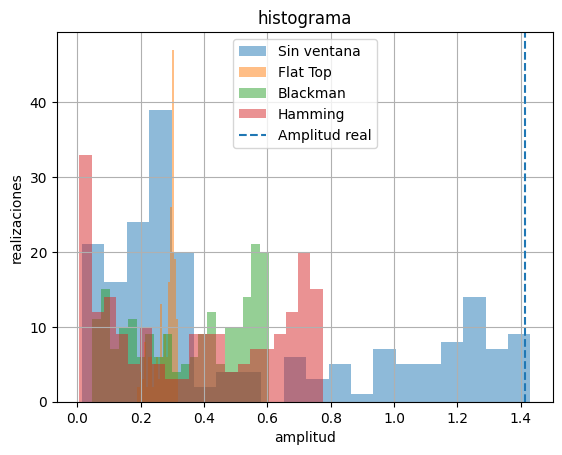

In [5]:
#%% HISTOGRAMA

plt.figure()

plt.hist(amod_evaluado, 20, alpha=0.5, label="Sin ventana")
plt.hist(amod_flattop, 20, alpha=0.5, label="Flat Top")
plt.hist(amod_blackman, 20, alpha=0.5, label="Blackman")
plt.hist(amod_hamming, 20, alpha=0.5, label="Hamming")

plt.axvline(a0, linestyle="--", label="Amplitud real")

plt.title("histograma")
plt.xlabel("amplitud")
plt.ylabel("realizaciones")
plt.grid(True)
plt.legend()
plt.show()

Figura 2: Histograma comparativo de las amplitudes estimadas utilizando distintas ventanas espectrales.

#### Sesgo y varianza
Finalmente, para evaluar cuantitativamente cada estimador de amplitud, se calcularon experimentalmente el sesgo y la varianza utilizando las 200 realizaciones generadas.
El sesgo se obtuvo como la diferencia promedio entre la amplitud estimada y la amplitud real de la señal:
$$
s_a = E{\hat a} - a_0
$$

mientras que la varianza se calculó como:
$$
v_a = E{(\hat a - E{\hat a})^2}
$$

Además del sesgo tradicional, también se calculó el sesgo absoluto promedio con el objetivo de medir el error medio sin considerar el signo de la diferencia respecto del valor real.

Estos cálculos se realizaron para cada una de las ventanas analizadas con el fin de comparar cómo afecta el ventaneo a la precisión y dispersión de los estimadores de amplitud.


In [6]:
#%% sesgo y varianza

#sin ventana
diferencia_sin = amod_evaluado - a0

sesgo_sin = np.mean(diferencia_sin)
sesgoMOD_sin = np.mean(np.abs(diferencia_sin))
varianza_sin = np.var(amod_evaluado)

#flattop
diferencia_flattop = amod_flattop - a0

sesgo_flattop = np.mean(diferencia_flattop)
sesgoMOD_flattop = np.mean(np.abs(diferencia_flattop))
varianza_flattop = np.var(amod_flattop)

#blackman
diferencia_blackman = amod_blackman - a0

sesgo_blackman = np.mean(diferencia_blackman)
sesgoMOD_blackman = np.mean(np.abs(diferencia_blackman))
varianza_blackman = np.var(amod_blackman)

#hamming
diferencia_hamming = amod_hamming - a0

sesgo_hamming = np.mean(diferencia_hamming)
sesgoMOD_hamming = np.mean(np.abs(diferencia_hamming))
varianza_hamming = np.var(amod_hamming)

print("Sin ventana:")
print("Sesgo =", sesgo_sin)
print("Sesgo absoluto =", sesgoMOD_sin)
print("Varianza =", varianza_sin)

print("Flat Top:")
print("Sesgo =", sesgo_flattop)
print("Sesgo absoluto =", sesgoMOD_flattop)
print("Varianza =", varianza_flattop)

print("Blackman:")
print("Sesgo =", sesgo_blackman)
print("Sesgo absoluto =", sesgoMOD_blackman)
print("Varianza =", varianza_blackman)

print("Hamming:")
print("Sesgo =", sesgo_hamming)
print("Sesgo absoluto =", sesgoMOD_hamming)
print("Varianza =", varianza_hamming)


Sin ventana:
Sesgo = -0.8778930801382194
Sesgo absoluto = 0.8780787081375802
Varianza = 0.20434563939000833
Flat Top:
Sesgo = -1.134894088672519
Sesgo absoluto = 1.134894088672519
Varianza = 0.001086085678979676
Blackman:
Sesgo = -1.060834539273259
Sesgo absoluto = 1.060834539273259
Varianza = 0.03281571242458149
Hamming:
Sesgo = -1.0463698388390366
Sesgo absoluto = 1.0463698388390366
Varianza = 0.07261378376564079


Tabla 1: Valores experimentales de sesgo y varianza obtenidos para el estimador de amplitud utilizando ventana rectangular, Flat Top, Blackman y Hamming para un SNR de 10 dB.

### Señal de 3dB
Con el objetivo de analizar la influencia del ruido sobre los estimadores espectrales, se repitió el mismo procedimiento experimental utilizando un SNR de 3 dB. Para ello, se mantuvo exactamente la misma metodología de generación de señales, aplicación de ventanas y cálculo de estimadores de amplitud y frecuencia, modificando únicamente la potencia del ruido gaussiano agregado a las realizaciones.


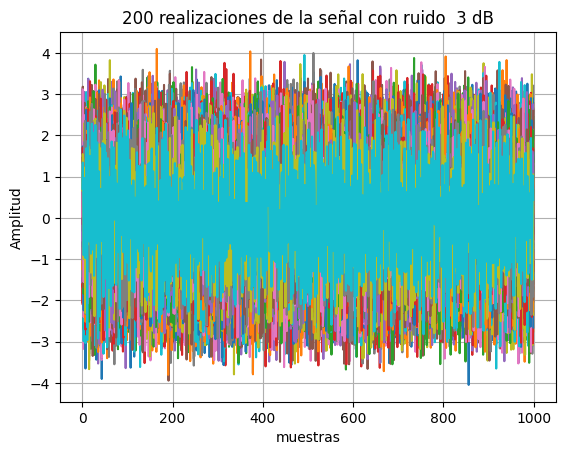

In [8]:
import numpy as np  #importar la libreria numpy
from scipy import signal
import matplotlib.pyplot as plt
np.random.seed(0)
N = 1000
R = 200

a0 = np.sqrt(2)

Omega0 = np.pi/2          # frecuencia angular central
fr = np.random.uniform(-2, 2, R)

Omega1 = Omega0 + fr * (2*np.pi/N) # Omega1 segun la consigna
Omega1 = Omega1.reshape(R, 1) # lo paso a vector columna: R x 1

n = np.arange(N)
n = n.reshape(1, N)

argumento = Omega1 * n #NumPy hace broadcasting automáticamente y te queda una matriz de: 200 X 1000
#%%ruido para SNR = 10 dB

mu = 0

SNR_db = 3
SNR = 10**(SNR_db/10)

P_sen = a0**2 / 2
P_ruido = P_sen / SNR

sigma = np.sqrt(P_ruido)

na = np.random.normal(mu, sigma, (R,N)) #RUIDO

#%% señal completa
xx = a0 * np.sin(argumento) + na

plt.figure()
plt.plot(xx.T)
plt.title("200 realizaciones de la señal con ruido  3 dB")
plt.xlabel("muestras")
plt.ylabel("Amplitud")
plt.grid()
plt.show()



Figura 3: Realizaciones de la señal senoidal con ruido gaussiano aditivo para un SNR de 3 dB.

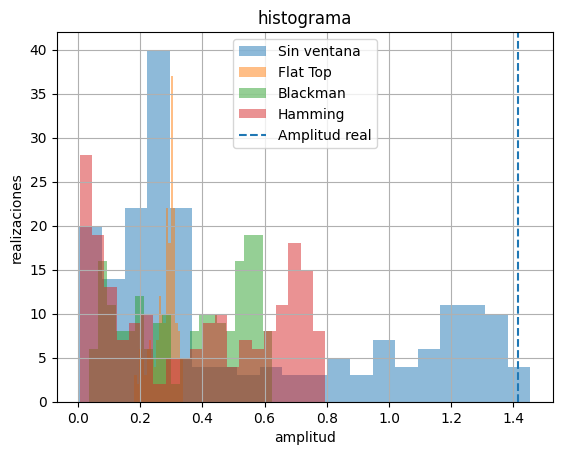

In [10]:
#%% estimador de amplitud 

a = np.fft.fft(xx)

amodulo = np.abs(a)
# evaluo en k0 = N/4
amod_evaluado = amodulo[:, N//4] * (2/N)

#%% estimador de frecuencia 

arg_max = np.argmax(amodulo, axis=1)
omega_estimado = 2*np.pi*arg_max/N
#%%FLATTOP

window_flattop = signal.windows.flattop(N)

xx_flattop = xx * window_flattop

fft_flattop = np.fft.fft(xx_flattop)

mod_flattop = np.abs(fft_flattop)

# estimador de amplitud
amod_flattop = mod_flattop[:, N//4] * (2/N)

# estimador de frecuencia
argmax_flattop = np.argmax(mod_flattop, axis=1)

omega_flattop = 2*np.pi*argmax_flattop/N
#%%BLACKMAN 
window_blackman = signal.windows.blackman(N)

xx_blackman = xx * window_blackman

fft_blackman = np.fft.fft(xx_blackman)

mod_blackman = np.abs(fft_blackman)

# estimador de amplitud 
amod_blackman = mod_blackman[:, N//4] * (2/N)

# estimador de frecuencia
argmax_blackman = np.argmax(mod_blackman, axis=1)
omega_blackman = 2*np.pi*argmax_blackman/N


#%% HAMMING
window_hamming = signal.windows.hamming(N)

xx_hamming = xx * window_hamming

fft_hamming = np.fft.fft(xx_hamming)

mod_hamming = np.abs(fft_hamming)

# estimador de amplitud
amod_hamming = mod_hamming[:, N//4] * (2/N)

# estimador de frecuencia
argmax_hamming = np.argmax(mod_hamming, axis=1)

omega_hamming = 2*np.pi*argmax_hamming/N

#%% HISTOGRAMA

plt.figure()

plt.hist(amod_evaluado, 20, alpha=0.5, label="Sin ventana")
plt.hist(amod_flattop, 20, alpha=0.5, label="Flat Top")
plt.hist(amod_blackman, 20, alpha=0.5, label="Blackman")
plt.hist(amod_hamming, 20, alpha=0.5, label="Hamming")

plt.axvline(a0, linestyle="--", label="Amplitud real")

plt.title("histograma")
plt.xlabel("amplitud")
plt.ylabel("realizaciones")
plt.grid(True)
plt.legend()
plt.show()


Figura 4: Histograma comparativo de las amplitudes estimadas utilizando distintas ventanas espectrales.

In [11]:
#%% sesgo y varianza

#sin ventana
diferencia_sin = amod_evaluado - a0

sesgo_sin = np.mean(diferencia_sin)
sesgoMOD_sin = np.mean(np.abs(diferencia_sin))
varianza_sin = np.var(amod_evaluado)

#flattop
diferencia_flattop = amod_flattop - a0

sesgo_flattop = np.mean(diferencia_flattop)
sesgoMOD_flattop = np.mean(np.abs(diferencia_flattop))
varianza_flattop = np.var(amod_flattop)

#blackman
diferencia_blackman = amod_blackman - a0

sesgo_blackman = np.mean(diferencia_blackman)
sesgoMOD_blackman = np.mean(np.abs(diferencia_blackman))
varianza_blackman = np.var(amod_blackman)

#hamming
diferencia_hamming = amod_hamming - a0

sesgo_hamming = np.mean(diferencia_hamming)
sesgoMOD_hamming = np.mean(np.abs(diferencia_hamming))
varianza_hamming = np.var(amod_hamming)

print("Sin ventana:")
print("Sesgo =", sesgo_sin)
print("Sesgo absoluto =", sesgoMOD_sin)
print("Varianza =", varianza_sin)

print("Flat Top:")
print("Sesgo =", sesgo_flattop)
print("Sesgo absoluto =", sesgoMOD_flattop)
print("Varianza =", varianza_flattop)

print("Blackman:")
print("Sesgo =", sesgo_blackman)
print("Sesgo absoluto =", sesgoMOD_blackman)
print("Varianza =", varianza_blackman)

print("Hamming:")
print("Sesgo =", sesgo_hamming)
print("Sesgo absoluto =", sesgoMOD_hamming)
print("Varianza =", varianza_hamming)


Sin ventana:
Sesgo = -0.8744423425264662
Sesgo absoluto = 0.8751520433934225
Varianza = 0.20190960521699786
Flat Top:
Sesgo = -1.1349205658433854
Sesgo absoluto = 1.1349205658433854
Varianza = 0.0012743917116897286
Blackman:
Sesgo = -1.0609777365973871
Sesgo absoluto = 1.0609777365973871
Varianza = 0.03315025364742407
Hamming:
Sesgo = -1.0446213672571083
Sesgo absoluto = 1.0446213672571083
Varianza = 0.07158021394780308


Tabla 2: Valores experimentales de sesgo y varianza obtenidos para el estimador de amplitud utilizando ventana rectangular, Flat Top, Blackman y Hamming para un SNR de 3 dB.

#### Analisis de resultados
A partir de los resultados obtenidos para SNR de 10 dB y 3 dB, puede observarse el efecto que producen tanto el ruido como el tipo de ventana sobre el desempeño de los estimadores espectrales de amplitud.

En primer lugar, las realizaciones temporales muestran que al disminuir el SNR aumenta la presencia de ruido sobre la señal. Para el caso de 3 dB las señales presentan una dispersión mayor respecto del caso de 10 dB,
En los histogramas comparativos se observa que la ventana rectangular (sin ventana) produce estimaciones de amplitud más cercanas al valor real:
$$
a_0 = \sqrt{2}
$$

Esto se refleja también en los valores de sesgo obtenidos experimentalmente, siendo la ventana rectangular la que presenta el menor error respecto de la amplitud real en ambos casos de SNR.

Por otro lado, las ventanas Flat Top, Blackman y Hamming presentan histogramas desplazados hacia amplitudes menores. Esto ocurre debido a la atenuación introducida por el ventaneo, ya que estas ventanas modifican la amplitud efectiva de la señal al multiplicarla en el dominio temporal. Como consecuencia, los estimadores obtenidos presentan un mayor sesgo respecto del valor esperado.
La ventana rectangular presenta menor sesgo pero mayor sensibilidad al leakage y al ruido, mientras que las demas ventanas reducen la dispersión de las estimaciones a costa de introducir una mayor atenuación sobre la amplitud estimada.

